# Malaysia E-Commerce Segment Growth Analysis

## The Question

Which customer segment — Business-to-Business (B2B), Business-to-Consumer (B2C), or Business-to-Government (B2G) — is actually driving Malaysia's e-commerce growth, and what does that mean for where a business should focus its investment?

A company deciding where to allocate e-commerce marketing and sales investment in Malaysia needs to know which segment is genuinely gaining momentum, not just which segment is largest today. Those are not always the same answer.

## The Answer

B2G recorded the fastest growth (30.5% CAGR, 2021–2024), but from a small base — contributing only RM18.6 billion in additional revenue over the period. B2B, despite a lower CAGR (7.2%), drove the largest absolute expansion, adding RM166.5 billion in new revenue — nine times more than B2G over the same window.

The right answer depends on time horizon. For firms prioritizing near-term revenue capture, B2B remains the stronger bet — its scale and consistent growth make it the safer, larger opportunity. For firms with a longer time horizon or existing government-sector relationships, B2G's 30.5% CAGR signals a segment worth entering early, before it matures and that growth rate normalizes.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the core dataset for this notebook
ecommerce = pd.read_csv('../data/processed/ecommerce_income.csv')
ecommerce

,year,income_rm_billion,domestic_rm_billion,international_rm_billion,b2b_rm_billion,b2c_rm_billion,b2g_rm_billion,source_document
0,2020,896.4,NaN,NaN,NaN,NaN,NaN,ictec-refyear2020_Income_of_E-Commerce_Transac...
1,2021,1037.2,932.7,104.5,713.1,308.9,15.2,ictec-refyear2021_Usage_of_ICT_and_E-Commerce_...
2,2022,1126.9,1003.5,123.4,786.5,312.6,27.8,ictec-refyear2023_Usage_of_ICT_and_E-Commerce_...
3,2023,1184.1,1053.0,131.1,817.1,336.6,30.4,ictec-refyear2024_Usage_of_ICT_and_E-Commerce_...
4,2024,1288.1,1150.1,138.0,879.6,374.7,33.8,ictec-refyear2024_Usage_of_ICT_and_E-Commerce_...


In [2]:
# House chart style: consistent palette, clean chrome, and a source-footnote helper
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#4a3aa7', '#e34948']
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#e1e0d9', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, consulting-deck style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)


## Which segment is largest today, and has that always been true?

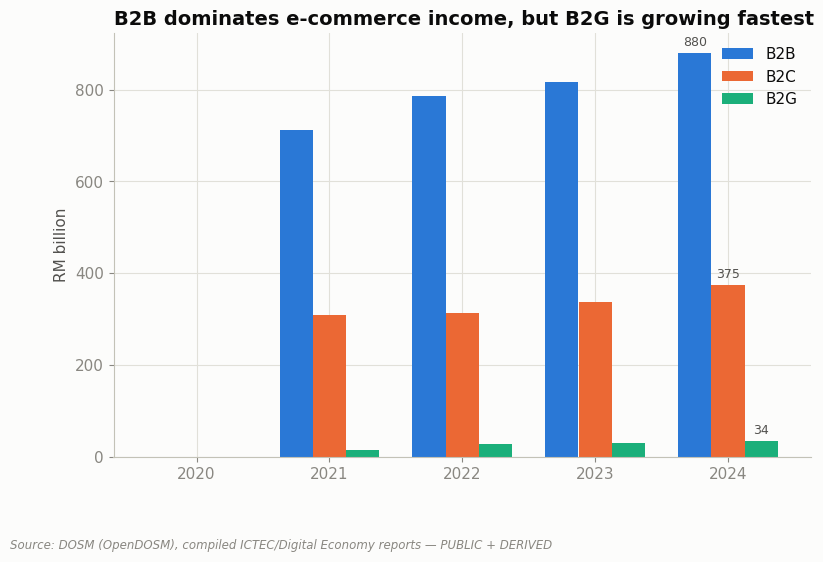

In [3]:
segments = ['b2b_rm_billion', 'b2c_rm_billion', 'b2g_rm_billion']
segment_data = ecommerce.set_index('year')[segments]

ax = segment_data.plot(kind='bar', figsize=(9, 5.5), width=0.75,
                        color=PALETTE[:3], edgecolor='none')
ax.set_title('B2B dominates e-commerce income, but B2G is growing fastest', loc='left')
ax.set_ylabel('RM billion')
ax.set_xlabel('')
ax.legend(['B2B', 'B2C', 'B2G'])
plt.xticks(rotation=0)

# Direct-label the most recent year only (2024) — the endpoint that matters
for container in ax.containers:
    labels = ['' if i != len(container) - 1 else f'{container[i].get_height():,.0f}'
              for i in range(len(container))]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9, color=INK_SECONDARY)

add_source(ax.figure, 'Source: DOSM (OpenDOSM), compiled ICTEC/Digital Economy reports — PUBLIC + DERIVED')
plt.show()


## Which segment is actually growing fastest?

Segment breakdowns are only available from 2021 onward (2020's source document reported only the total). CAGR below is calculated over 2021–2024.

In [4]:
# Restrict to years with segment data (excludes 2020)
segment_years = ecommerce[ecommerce['year'] >= 2021].set_index('year')[segments]

# Year-on-year % growth for each segment
yoy_growth = segment_years.pct_change() * 100
print("Year-on-year growth (%):")
print(yoy_growth.round(1))

# Compound Annual Growth Rate, 2021 -> 2024 (3 years of growth)
years_elapsed = 2024 - 2021
cagr = ((segment_years.loc[2024] / segment_years.loc[2021]) ** (1 / years_elapsed) - 1) * 100
print("\nCAGR 2021-2024 (%):")
print(cagr.round(1))

Year-on-year growth (%):
      b2b_rm_billion  b2c_rm_billion  b2g_rm_billion
year                                                
2021             NaN             NaN             NaN
2022            10.3             1.2            82.9
2023             3.9             7.7             9.4
2024             7.6            11.3            11.2

CAGR 2021-2024 (%):
b2b_rm_billion     7.2
b2c_rm_billion     6.6
b2g_rm_billion    30.5
dtype: float64


## Does B2C's growth hold up against the wider economy, or is it riding a general retail recovery?

If B2C e-commerce is growing faster than retail trade overall, that signals a real shift toward digital channels — not just a rising tide lifting all boats.

In [5]:
retail = pd.read_csv('../data/raw/iowrt.csv')

# Keep only absolute sales values, and only December of each year for a clean annual comparison
retail_annual = retail[
    (retail['series'] == 'abs') &
    (retail['date'].str.endswith('-12-01'))
].copy()
retail_annual['year'] = retail_annual['date'].str[:4].astype(int)
retail_annual = retail_annual.set_index('year')['sales']

# CAGR for overall retail sales, same window as B2C
retail_cagr = ((retail_annual.loc[2024] / retail_annual.loc[2021]) ** (1/3) - 1) * 100

print(f"B2C e-commerce CAGR (2021-2024): {cagr['b2c_rm_billion']:.1f}%")
print(f"Overall retail trade CAGR (2021-2024): {retail_cagr:.1f}%")

B2C e-commerce CAGR (2021-2024): 6.6%
Overall retail trade CAGR (2021-2024): 8.0%


## Interpreting the 2020 gap

The exclusion of 2020 from CAGR calculations was intentional, not arbitrary. E-commerce income grew 32.7% year-on-year in 2020 — more than four times the average annual growth observed across 2021–2024 — reflecting an extraordinary pandemic-driven shock rather than a sustainable trend. Including it would have distorted the long-term growth rate estimates in Section 3.2. That said, 2020 remains analytically valuable on its own terms: it illustrates the structural acceleration e-commerce experienced during the pandemic and provides important context for understanding the "normalization" observed in the years that followed.

## Strategic Recommendation

- **B2B should be the primary investment priority for firms seeking scale** — it contributed the largest absolute revenue gain (RM166.5 billion, 2021–2024) of any segment, despite a moderate CAGR.
- **B2G represents a promising niche opportunity for startups or GovTech-focused firms** — its 30.5% CAGR signals a segment worth entering early, though its small base means near-term revenue impact is limited.
- **B2C remains an important, stable segment**, but has entered a post-pandemic normalization phase, growing more slowly than overall retail trade in the same window.

## Confidence & Caveats

**Confidence:** High for relative segment comparisons (B2B vs. B2C vs. B2G), since all figures come from the same DOSM dataset series. Confidence in the 2022–2023 figures specifically is higher than 2020, 2021, or 2024, since those two years are corroborated across two independent DOSM publications rather than one.

**Caveats:**
- Segment-level CAGR is calculated over a short window (2021–2024) — three years of growth is not a long-term trend guarantee.
- CAGR describes *what* grew, not *why* — it cannot explain the causes behind B2G's surge or B2C's slowdown.
- B2G's exceptional growth rate is influenced by a low starting base (RM15.2 billion in 2021) and may not persist as the segment matures.
- The B2C-vs-retail comparison (Section 3.3) should not be read as evidence that e-commerce is "underperforming" — the two datasets measure different, only partially overlapping markets.